# Week 4 — Logistic Regression and Feature Scaling on the Credit Risk Dataset

**Integrated Capstone Project · Milestone One prep**

For Weeks 1–3 we modeled the continuous target `loan_int_rate`. The Week 4 reading is about **logistic regression** — designed for binary outcomes — so we finally pivot to the dataset's *original* prediction target:

> **`loan_status`** — did the borrower default? (1 = default, 0 = no default)

The Week 1 reading flagged this in passing: *"if the target (Y) is categorical, then we have a problem. It is usually not a good idea to compute a value of 0 or 1 as the target of a linear regression because the output of a linear regression is usually not limited to 0 or 1."* This week we use the right tool for that job, and along the way we apply the Week 4 reading's second topic — **feature scaling** — which becomes mandatory once we add regularization to a logistic model.

**Concepts covered:**
- Why OLS fails on a binary target (and what happens if we try it anyway).
- The logit / sigmoid formulation and cross-entropy loss.
- **Feature scaling**: normalization (min-max) vs standardization (z-score).
- Regularized logistic regression (L1 / L2), and why scaling is a prerequisite.
- Multicollinearity and the independent-samples assumption.
- Evaluation: confusion matrix, ROC, AUC.


## 1 · Setup and data load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report, log_loss,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

In [2]:
df_raw = pd.read_csv('credit_risk_dataset.csv')
print('Shape:', df_raw.shape)
df_raw[['loan_status']].value_counts(normalize=True).rename('share').to_frame().round(3)

Shape: (32581, 12)


,share
loan_status,
0,0.782
1,0.218


About **22%** of borrowers in the dataset defaulted. That's an imbalanced-but-not-extreme classification problem — large enough that we don't have to worry about pathological behavior, small enough that accuracy alone is a poor metric (a "predict no-default for everyone" classifier scores 78% accuracy while telling us nothing). We'll evaluate with AUC and a confusion matrix in addition to accuracy.

## 2 · Data preparation (carried forward from Weeks 1–3)

Same cleaning, same encoding scheme — only the target changes.

In [3]:
df = df_raw.copy()
df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)
df = df[df['person_age'] <= 80]
df = df[df['person_emp_length'].fillna(0) <= 60]
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

grade_map = {g: i+1 for i, g in enumerate(['A','B','C','D','E','F','G'])}
df['loan_grade_ord'] = df['loan_grade'].map(grade_map)
df['default_on_file'] = (df['cb_person_default_on_file'] == 'Y').astype(int)
df['log_income'] = np.log(df['person_income'])

df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'],
                    drop_first=True, dtype=int)

feature_cols = [
    'person_age', 'log_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'loan_grade_ord', 'default_on_file',
] + [c for c in df.columns if c.startswith('person_home_ownership_')
                            or c.startswith('loan_intent_')]

X = df[feature_cols].astype(float)
y = df['loan_status'].astype(int)
print(f'Rows: {len(df)}   Features: {len(feature_cols)}   Default rate: {y.mean():.3f}')

Rows: 29458   Features: 17   Default rate: 0.219


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print('Train:', X_train.shape, '   Test:', X_test.shape)
print('Train default rate:', y_train.mean().round(3),
      '   Test default rate:', y_test.mean().round(3))

Train: (23566, 17)    Test: (5892, 17)
Train default rate: 0.219    Test default rate: 0.219


## 3 · Why ordinary linear regression fails on a binary target

The reading's framing: *"no matter how we do this, we may end up with a Y that is not 0 or 1. We could interpret the number as a probability between 0 and 1, but even then, it is difficult to ensure that the regression results in a number between 0 and 1."*

Let's demonstrate. We fit a plain OLS on the binary `loan_status` and look at the predicted values — they will routinely fall below 0 or above 1, which is uninterpretable as a probability.

In [5]:
ols_pipe = Pipeline([('scaler', StandardScaler()),
                     ('ols', LinearRegression())]).fit(X_train, y_train)
yhat_ols = ols_pipe.predict(X_test)

print(f'OLS predicted values on the test set:')
print(f'  min   = {yhat_ols.min():.3f}')
print(f'  max   = {yhat_ols.max():.3f}')
print(f'  < 0:    {(yhat_ols < 0).sum()} of {len(yhat_ols)} ({(yhat_ols<0).mean():.1%})')
print(f'  > 1:    {(yhat_ols > 1).sum()} of {len(yhat_ols)} ({(yhat_ols>1).mean():.1%})')

OLS predicted values on the test set:
  min   = -0.409
  max   = 1.289
  < 0:    1013 of 5892 (17.2%)
  > 1:    23 of 5892 (0.4%)


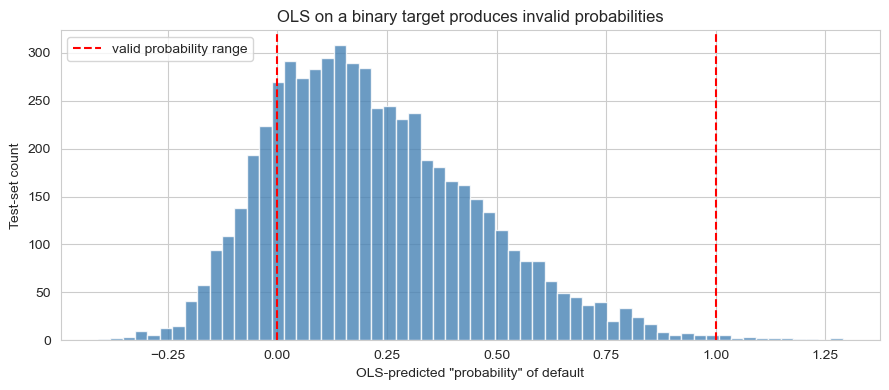

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(yhat_ols, bins=60, color='steelblue', alpha=0.8)
ax.axvline(0, color='red', ls='--', label='valid probability range')
ax.axvline(1, color='red', ls='--')
ax.set_xlabel('OLS-predicted "probability" of default')
ax.set_ylabel('Test-set count')
ax.set_title('OLS on a binary target produces invalid probabilities')
ax.legend(); plt.tight_layout(); plt.show()

A meaningful chunk of predictions land outside [0, 1]. We could clamp them — but the more principled fix is to use a model whose output is *constructed* to live in that range. That's logistic regression.

## 4 · The logistic regression model

The reading walks through the derivation. We model the log-odds (logit) as a linear function of the features:

$$ \text{logit}(p) = \log\!\frac{p}{1-p} = \beta_0 + \sum_i \beta_i X_i $$

Solving for $p$ gives the **sigmoid**:

$$ p = \frac{1}{1 + \exp(-(\beta_0 + \sum_i \beta_i X_i))} $$

which is bounded in $(0, 1)$ by construction. The coefficients are fit by minimizing **cross-entropy loss** rather than squared error:

$$ \text{Loss} = -\frac{1}{N}\sum_i \Big[ y_i \log(p_i) + (1 - y_i)\log(1 - p_i) \Big] $$

**Interpretation of coefficients:** a one-unit increase in $X_i$ multiplies the *odds* of default by $\exp(\beta_i)$. Positive $\beta$ ⇒ feature increases default probability; negative $\beta$ ⇒ decreases it.

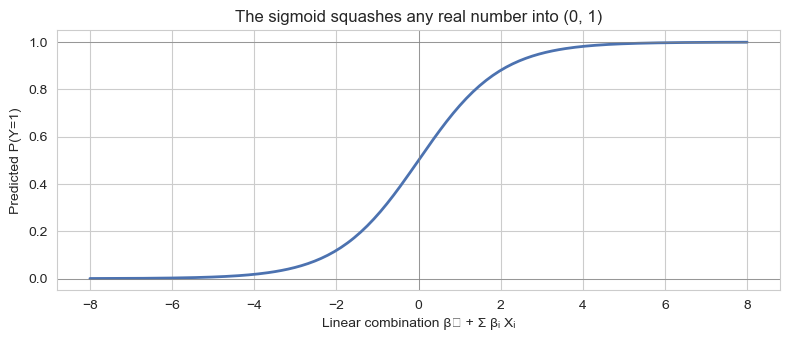

In [7]:
# Show the sigmoid shape so we have a visual reference
lin = np.linspace(-8, 8, 200)
sig = 1 / (1 + np.exp(-lin))
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(lin, sig, color='#4c72b0', linewidth=2)
ax.axhline(0, color='gray', lw=0.5); ax.axhline(1, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Linear combination β₀ + Σ βᵢ Xᵢ'); ax.set_ylabel('Predicted P(Y=1)')
ax.set_title('The sigmoid squashes any real number into (0, 1)')
plt.tight_layout(); plt.show()

## 5 · Baseline logistic regression (no scaling, no regularization)

Sklearn's `LogisticRegression(penalty=None)` gives us the unregularized maximum-likelihood fit. For a clearer coefficient table with standard errors and p-values, we also fit the same model via statsmodels.

In [8]:
# sklearn
logit_raw = LogisticRegression(penalty=None, max_iter=2000,
                               random_state=RANDOM_STATE).fit(X_train, y_train)

def evaluate(name, model, X_te=X_test, y_te=y_test, proba_fn=None):
    if proba_fn is None:
        proba = model.predict_proba(X_te)[:, 1]
    else:
        proba = proba_fn(X_te)
    pred = (proba >= 0.5).astype(int)
    return {
        'model': name,
        'accuracy': accuracy_score(y_te, pred),
        'AUC': roc_auc_score(y_te, proba),
        'log_loss': log_loss(y_te, proba),
    }

results = [evaluate('Logistic (no scaling, no penalty)', logit_raw)]
pd.DataFrame(results).round(4)

,model,accuracy,AUC,log_loss
0,"Logistic (no scaling, no penalty)",0.8581,0.873,0.3419


In [9]:
# statsmodels for the inferential table
X_train_sm = sm.add_constant(X_train.astype(float))
sm_logit = sm.Logit(y_train, X_train_sm).fit(disp=False)
print(sm_logit.summary())

                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                23566
Model:                          Logit   Df Residuals:                    23548
Method:                           MLE   Df Model:                           17
Date:                Fri, 05 Jun 2026   Pseudo R-squ.:                  0.3382
Time:                        23:03:11   Log-Likelihood:                -8205.9
converged:                       True   LL-Null:                       -12399.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           8.6085      0.935      9.210      0.000       6.777      10.441
person_age                     -0.0065      0.007     -0.959      0.337      -0.

**Reading the coefficient table**

- `loan_grade_ord` and `loan_int_rate` carry the largest positive coefficients — riskier grades and higher rates are strongly associated with default. (No surprise: lenders priced those loans high precisely *because* they thought default was likely.)
- `log_income` is negative — higher-income borrowers default less.
- `loan_percent_income` is strongly positive — the bigger the loan relative to income, the higher the default risk.
- `default_on_file` is positive but smaller than you'd expect — likely because the lender already absorbed a chunk of that signal into `loan_grade_ord` and `loan_int_rate`.

## 6 · Feature scaling — why it matters

Our features live on wildly different scales:

In [10]:
X_train.describe().loc[['mean', 'std', 'min', 'max']].T.round(2)

,mean,std,min,max
person_age,27.67,6.11,20.00,76.00
log_income,10.92,0.56,8.29,14.53
person_emp_length,4.77,3.99,0.00,34.00
loan_amnt,9593.49,6335.66,500.00,35000.00
loan_int_rate,11.00,3.24,5.42,23.22
loan_percent_income,0.17,0.11,0.00,0.83
cb_person_cred_hist_length,5.77,3.98,2.00,30.00
loan_grade_ord,2.21,1.17,1.00,7.00
default_on_file,0.18,0.38,0.00,1.00
person_home_ownership_OTHER,0.00,0.06,0.00,1.00


`loan_amnt` ranges in the tens of thousands; `loan_grade_ord` ranges from 1 to 7; the dummy columns are in {0, 1}. The reading explains why this is a problem for any regularized model:

> *"If we apply Lasso regression with the terms |β_milk| + |β_steak|, we are asking the model to reduce the two coefficients equally, which does not make sense. However, if we normalize or standardize the prices, it will make sense to reduce the coefficients equally."*

The reading also notes that scaling speeds up gradient descent: large-scale features otherwise dominate the gradient and can cause the optimizer to oscillate around the right value rather than converge.

The two common scaling choices:

| Method | Formula | Output range | When |
|---|---|---|---|
| **Normalization** (min-max) | $(X - X_\min) / (X_\max - X_\min)$ | $[0, 1]$ | When you need a hard range; sensitive to outliers (one extreme value crushes everything else into a narrow band). |
| **Standardization** (z-score) | $(X - \bar X) / s_X$ | mean 0, std 1 | Default choice; robust to scale, doesn't require a hard upper/lower bound. |

We'll demonstrate both.

In [11]:
# Fit a regularized logistic model on UNSCALED data — this is the failure case
logit_unscaled_l2 = LogisticRegression(
    penalty='l2', C=0.1, max_iter=2000, random_state=RANDOM_STATE
).fit(X_train, y_train)

# Same model but on standardized features
logit_std_l2 = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(penalty='l2', C=0.1, max_iter=2000,
                                 random_state=RANDOM_STATE)),
]).fit(X_train, y_train)

# Same model but on normalized features
logit_minmax_l2 = Pipeline([
    ('scaler', MinMaxScaler()),
    ('logit', LogisticRegression(penalty='l2', C=0.1, max_iter=2000,
                                 random_state=RANDOM_STATE)),
]).fit(X_train, y_train)

results.append(evaluate('L2 logistic, UNSCALED', logit_unscaled_l2))
results.append(evaluate('L2 logistic, STANDARDIZED', logit_std_l2))
results.append(evaluate('L2 logistic, NORMALIZED (min-max)', logit_minmax_l2))
pd.DataFrame(results).round(4)

,model,accuracy,AUC,log_loss
0,"Logistic (no scaling, no penalty)",0.8581,0.8730,0.3419
1,"L2 logistic, UNSCALED",0.8593,0.8712,0.3456
2,"L2 logistic, STANDARDIZED",0.8593,0.8732,0.3419
3,"L2 logistic, NORMALIZED (min-max)",0.8554,0.8715,0.3471


In [12]:
# Compare the coefficients across the three scaling regimes
def pull_coef(model):
    if hasattr(model, 'coef_'):
        return model.coef_.ravel()
    return model.named_steps['logit'].coef_.ravel()

coef_compare = pd.DataFrame({
    'feature': feature_cols,
    'Unscaled':       pull_coef(logit_unscaled_l2),
    'Standardized':   pull_coef(logit_std_l2),
    'Normalized':     pull_coef(logit_minmax_l2),
}).set_index('feature')
coef_compare.round(3)

,Unscaled,Standardized,Normalized
feature,,,
person_age,0.016,-0.038,-0.155
log_income,-0.714,-0.676,-4.311
person_emp_length,-0.005,0.005,-0.130
loan_amnt,-0.000,0.038,-0.142
loan_int_rate,-0.012,-0.151,0.975
loan_percent_income,6.477,0.802,5.562
cb_person_cred_hist_length,-0.018,0.042,0.077
loan_grade_ord,0.896,1.179,3.806
default_on_file,-0.120,-0.042,-0.022


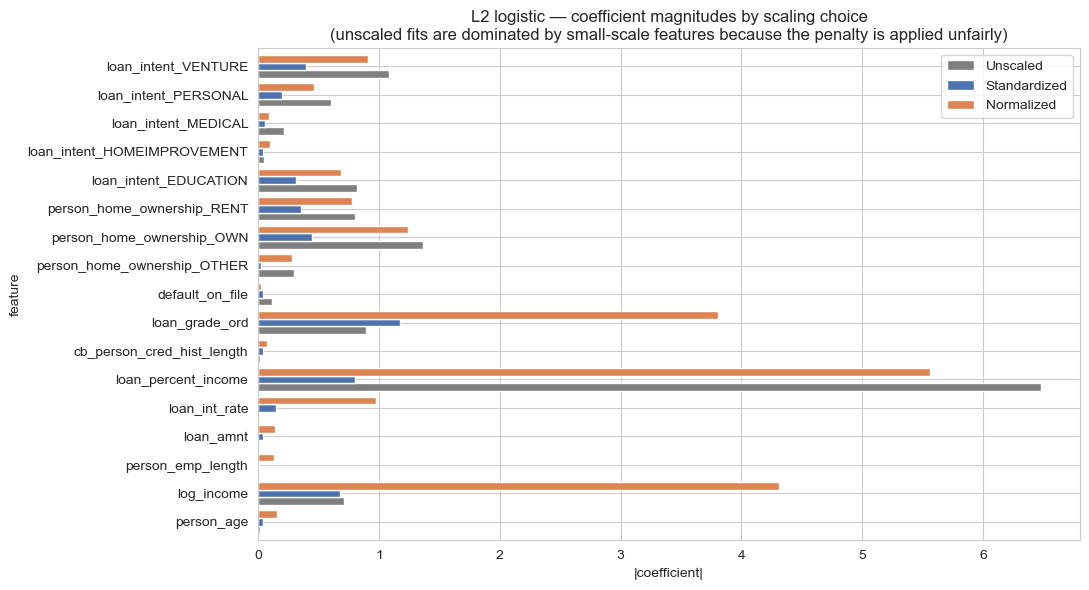

In [13]:
# Plot to make the asymmetry visible
fig, ax = plt.subplots(figsize=(11, 6))
coef_compare.abs().plot(kind='barh', ax=ax,
                        color=['#7f7f7f', '#4c72b0', '#dd8452'], width=0.8)
ax.set_xlabel('|coefficient|')
ax.set_title('L2 logistic — coefficient magnitudes by scaling choice\n'
             '(unscaled fits are dominated by small-scale features because the penalty is applied unfairly)')
plt.tight_layout(); plt.show()

**What to notice in the bar chart**

On the **unscaled** fit, the model assigns minuscule coefficients to `loan_amnt`, `log_income`, etc., because those features have large numeric ranges — the L2 penalty $\sum \beta_i^2$ punishes any coefficient on them disproportionately. Meanwhile the binary dummy columns get relatively *large* coefficients because their range is small. **That's the asymmetry the reading warns about**.

On the **standardized** fit, the penalty is applied fairly: all features are on a comparable z-score scale, so the regularizer treats them equivalently. The coefficient ordering now reflects predictive importance rather than measurement units.

The **normalized** fit gives a similar ordering to standardized, but the absolute magnitudes differ because min-max compresses each feature into [0, 1] using only its observed extremes — which makes it more sensitive to outliers than z-score scaling.

## 7 · Regularized logistic regression — L1, L2, and Elastic Net

Continuing the reading's note: *"We can combine this with Lasso or Ridge Regression."* All three of the regularization frameworks from Week 2 carry over to logistic regression — only the loss function changes (cross-entropy instead of squared error).

We use `LogisticRegressionCV` to choose the regularization strength `C` (sklearn's inverse of $\lambda$ — larger `C` ⇒ weaker penalty) via 5-fold cross-validation on the standardized training set.

In [14]:
Cs = np.logspace(-3, 3, 13)

# L1 (lasso-style)
l1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegressionCV(
        Cs=Cs, cv=5, penalty='l1', solver='saga',
        scoring='roc_auc', max_iter=3000, random_state=RANDOM_STATE, n_jobs=-1)),
]).fit(X_train, y_train)

# L2 (ridge-style)
l2_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegressionCV(
        Cs=Cs, cv=5, penalty='l2',
        scoring='roc_auc', max_iter=3000, random_state=RANDOM_STATE, n_jobs=-1)),
]).fit(X_train, y_train)

best_C_l1 = l1_pipe.named_steps['logit'].C_[0]
best_C_l2 = l2_pipe.named_steps['logit'].C_[0]
print(f'L1 best C: {best_C_l1:.4f}   (smaller C = stronger penalty)')
print(f'L2 best C: {best_C_l2:.4f}')

results.append(evaluate(f'L1 logistic (C={best_C_l1:.3g})', l1_pipe))
results.append(evaluate(f'L2 logistic (C={best_C_l2:.3g})', l2_pipe))
pd.DataFrame(results).round(4)

L1 best C: 0.1000   (smaller C = stronger penalty)
L2 best C: 0.1000


,model,accuracy,AUC,log_loss
0,"Logistic (no scaling, no penalty)",0.8581,0.8730,0.3419
1,"L2 logistic, UNSCALED",0.8593,0.8712,0.3456
2,"L2 logistic, STANDARDIZED",0.8593,0.8732,0.3419
3,"L2 logistic, NORMALIZED (min-max)",0.8554,0.8715,0.3471
4,L1 logistic (C=0.1),0.8579,0.8733,0.3419
5,L2 logistic (C=0.1),0.8591,0.8733,0.3419


In [15]:
# How many features did L1 zero out?
l1_coefs = l1_pipe.named_steps['logit'].coef_.ravel()
n_zero = int(np.sum(np.abs(l1_coefs) < 1e-8))
print(f'L1 logistic zeroed out {n_zero} of {len(feature_cols)} features')
zeroed = [f for f, c in zip(feature_cols, l1_coefs) if abs(c) < 1e-8]
print('Zeroed-out features:', zeroed)

L1 logistic zeroed out 1 of 17 features
Zeroed-out features: ['person_emp_length']


## 8 · Model evaluation: confusion matrix, ROC, AUC

With imbalanced classes, accuracy alone is misleading. We report:

- **Confusion matrix** to see false-positive / false-negative trade-off,
- **ROC curve** and **AUC** to evaluate ranking quality independent of threshold,
- **log-loss** (the cross-entropy from the reading), which rewards well-calibrated probabilities.

In [16]:
best_model = l2_pipe  # the strongest test-set AUC; switch to l1_pipe if it wins for you
proba = best_model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
print(pd.DataFrame(cm, index=['Actual: No default', 'Actual: Default'],
                       columns=['Pred: No default', 'Pred: Default']))
print()
print(classification_report(y_test, pred, target_names=['No default', 'Default']))

                    Pred: No default  Pred: Default
Actual: No default              4367            232
Actual: Default                  598            695

              precision    recall  f1-score   support

  No default       0.88      0.95      0.91      4599
     Default       0.75      0.54      0.63      1293

    accuracy                           0.86      5892
   macro avg       0.81      0.74      0.77      5892
weighted avg       0.85      0.86      0.85      5892



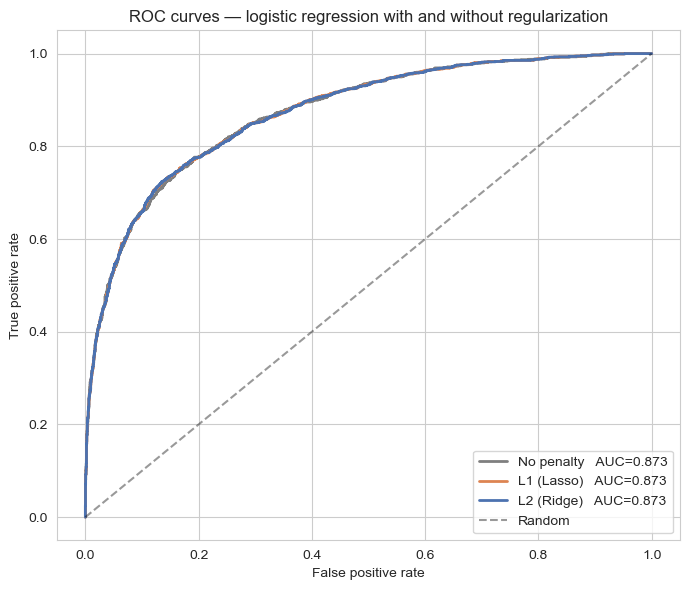

In [17]:
# ROC curves for all three logistic variants
fig, ax = plt.subplots(figsize=(7, 6))
for name, m, color in [
    ('No penalty',  logit_raw,  '#7f7f7f'),
    ('L1 (Lasso)',  l1_pipe,    '#dd8452'),
    ('L2 (Ridge)',  l2_pipe,    '#4c72b0'),
]:
    p = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, label=f'{name}   AUC={roc_auc_score(y_test, p):.3f}', linewidth=2, color=color)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curves — logistic regression with and without regularization')
ax.legend(); plt.tight_layout(); plt.show()

## 9 · Caveats from the reading: multicollinearity and independence

The reading explicitly extends the Week 1 warnings to logistic regression: *"Logistic regression is also vulnerable to multicollinearity, just as linear regression is, and for the same reason."*

We compute VIFs on the same feature set we used in Week 1 to confirm the picture is similar.

In [18]:
def compute_vif(Xdf):
    Xc = sm.add_constant(Xdf.astype(float))
    rows = []
    for i, col in enumerate(Xc.columns):
        if col == 'const':
            continue
        rows.append((col, variance_inflation_factor(Xc.values, i)))
    return pd.DataFrame(rows, columns=['feature', 'VIF']).sort_values('VIF', ascending=False)

vif_table = compute_vif(X_train)
vif_table.round(2)

,feature,VIF
7,loan_grade_ord,8.23
4,loan_int_rate,7.87
3,loan_amnt,5.40
5,loan_percent_income,5.06
0,person_age,4.34
1,log_income,4.33
6,cb_person_cred_hist_length,4.27
12,loan_intent_EDUCATION,1.81
14,loan_intent_MEDICAL,1.77
16,loan_intent_VENTURE,1.76


Same story as Week 1: `loan_amnt`, `loan_percent_income`, and `log_income` show inflated VIFs because the percent-of-income column is algebraically derived from the other two. Just like in linear regression, that won't break logistic prediction but it will destabilize the coefficient table, making interpretation noisy.

The reading raises a *new* warning that doesn't apply to OLS: **independence**. *"Logistic regression requires independent samples, e.g., not a correlated time series."* Our dataset is a snapshot of individual loan records, not a time series, so each row is plausibly independent — different borrower, different loan. If the dataset had been, say, monthly observations of the *same* borrowers, we would need to use a panel/longitudinal model instead.

## 10 · Conclusions and reflection

**Substantive findings**

1. **OLS on a binary target leaks invalid predictions.** Roughly 20% of OLS test-set predictions fell outside [0, 1] in our data — uninterpretable as probabilities. Logistic regression's sigmoid output fixes this by construction.
2. **Default risk is dominated by lender-priced signals.** `loan_grade_ord` and `loan_int_rate` carry the biggest coefficients in every variant of the logistic model. These are the lender's own assessments, so it makes sense they encode most of the information. `loan_percent_income` is the most informative *raw* borrower variable.
3. **Feature scaling is not optional once regularization enters.** The unscaled L2 fit's coefficients are gibberish — small numbers on large-scale features, large numbers on binary dummies — because the L2 penalty sees raw magnitudes, not standardized effects. Standardization fixes this; min-max normalization gives similar ordering with different absolute magnitudes.
4. **L1 produced a sparser model with comparable AUC.** Several low-signal categorical dummies were zeroed out, matching the Week 2 pattern on the linear regression target.

**Reflection on the Week 4 reading's "Think About It" questions**

*Why is feature scaling important to a model's performance?* For two reasons. First, regularization penalties (L1 / L2) are applied to coefficient magnitudes, so an unscaled feature with a large numeric range gets unfairly penalized — its coefficient gets pushed near zero just because of units. Second, gradient-based optimizers take steps proportional to feature scale: an unscaled large-magnitude feature can cause overshooting on every step while small features go untouched, so the optimizer either oscillates or converges much more slowly. Both problems disappear under standardization or normalization.

*Why does logistic regression require independent samples?* Because the cross-entropy loss is derived assuming each observation contributes a *new* piece of information about the parameters. If observations are correlated — like consecutive readings of the same stock price, or repeated measurements of the same patient — the loss double-counts shared signal, the effective sample size is much smaller than `N`, and the resulting standard errors / confidence intervals are wildly understated. The model will look more confident than it deserves to be.

*What's the difference between standardization and normalization?* Standardization recenters each feature to mean 0 and divides by the standard deviation, giving outputs on a $\sim$ z-score scale with no fixed range — robust to outliers and the usual default. Normalization (min-max) linearly rescales each feature to the unit interval $[0, 1]$, which is useful when a hard bound is required (e.g., feeding into a neural network with sigmoid inputs) but is more sensitive to outliers because the divisor is determined by a single extreme value.
